# Unsupervised Learning

This notebook applies unsupervised learning techniques to identify latent structures in the housing dataset.
The goal is to discover natural groupings of properties based on shared characteristics.

In [1]:
# Core data and math libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import os

# Unsupervised Machine Learning tools
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
import umap
import hdbscan

# Load the engineered features
df_3 = pd.read_csv('../data/processed/df2.csv')

# Standardize the data to ensure equal weighting of all features in distance calculations
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_3)

In [2]:
df_3.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,...,SaleCondition,SalePrice,BsmtFinRatio,LivingAreaPerRoom,AgeAtSale,RemodAge,TotalBath,TotalPorchSF,HouseAge,Remodeled
0,60,3,65.0,8450,3,3,4,0,5,2,...,4,208500,0.500585,213.750000,5,5,3.5,61,5,0
1,20,3,80.0,9600,3,3,2,0,24,1,...,4,181500,1.000000,210.333333,31,31,2.5,298,31,0
2,60,3,68.0,11250,0,3,4,0,5,2,...,4,223500,0.515118,297.666667,7,6,3.5,42,7,1
3,60,3,84.0,14260,0,3,2,0,15,2,...,4,250000,0.520928,244.222222,8,8,3.5,276,8,0
4,50,3,85.0,14115,0,3,4,0,11,2,...,4,143000,0.584435,272.400000,16,14,2.5,70,16,1


## 1. K-Means Clustering
We begin with K-Means, the industry standard for centroid-based clustering. Since K-Means requires us to pre-define the number of clusters ($k$), we use the **Elbow Method** to plot the inertia and identify the optimal inflection point.

C:\Users\aminl\anaconda3\envs\pytorch-gpu\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\aminl\anaconda3\envs\pytorch-gpu\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\aminl\anaconda3\envs\pytorch-gpu\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\aminl\anaconda3\envs\pytorch-gpu\Lib\site-packages\sklearn\cluster\_kmeans.p

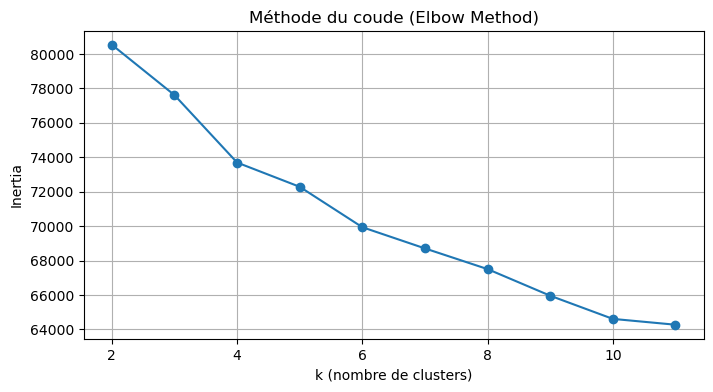

In [3]:
# Limit MKL threads to prevent memory leaks in KMeans (Best Practice)
os.environ["OMP_NUM_THREADS"] = "6"

inertias = []
K = range(2, 12)  

# Test cluster counts from 2 to 11 to find the 'elbow'
for k in K:
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertias, marker="o")
plt.title("Méthode du coude (Elbow Method)")
plt.xlabel("k (nombre de clusters)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

In [4]:
# ---------------------------------------------------------
# Apply final KMeans model using the optimally identified k
# ---------------------------------------------------------
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, n_init="auto", random_state=42)
df_3["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)
labels_km = df_3["KMeans_Cluster"].values

C:\Users\aminl\anaconda3\envs\pytorch-gpu\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


## 1.2 Dimensionality Reduction (UMAP) & Density Clustering (HDBSCAN)
K-Means forces every point into a cluster, even outliers, and assumes spherical clusters. To model the real-world housing market more accurately, we combine **UMAP** (for non-linear dimensionality reduction) with **HDBSCAN** (for density-based clustering). 

This powerful combination allows us to identify complex, irregularly shaped market segments while isolating highly unique anomaly properties as "noise."

In [5]:
# 1. Reduce high-dimensional housing data to 3 components using UMAP
umap_3d = umap.UMAP(
    n_neighbors=15, min_dist=0.0, n_components=3, metric="manhattan", random_state=42
)
X_umap3 = umap_3d.fit_transform(X_scaled)

# 2. Apply HDBSCAN on the dense 3D space
hdb = hdbscan.HDBSCAN(
    min_cluster_size=150, min_samples=1, metric="manhattan", 
    cluster_selection_method="leaf", cluster_selection_epsilon=0.01
)
hdb_labels = hdb.fit_predict(X_umap3)
df_3["HDBSCAN_Cluster"] = hdb_labels

# Noise points are labeled as '-1' by HDBSCAN
print(f"Noise proportion: {(hdb_labels == -1).mean():.4f}")

C:\Users\aminl\anaconda3\envs\pytorch-gpu\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Noise proportion: 0.1612


C:\Users\aminl\anaconda3\envs\pytorch-gpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\aminl\anaconda3\envs\pytorch-gpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


## 1.3 Model Evaluation & Comparison
Evaluating unsupervised learning requires internal mathematical metrics, as we do not have "true" labels to check against. We compare our models using:
* **Silhouette Score:** Measures how similar an object is to its own cluster compared to other clusters (Higher is better).
* **Davies-Bouldin Index:** Measures the average 'similarity' between clusters (Lower is better).
* **Calinski-Harabasz Index:** Ratio of variance between clusters to variance within clusters (Higher is better).
* **Stability (ARI):** Measures how consistently the algorithm finds the same clusters across different random seeds.

### 1.4 Metrics Results

In [6]:
# ============================================================
# Internal Quality Metrics (KMeans)
# ============================================================

sil_km = silhouette_score(X_scaled, labels_km)
db_km  = davies_bouldin_score(X_scaled, labels_km)
ch_km  = calinski_harabasz_score(X_scaled, labels_km)

# ============================================================
# Stability (Average ARI over multiple KMeans runs)
# ============================================================

n_runs = 5
ari_scores = []

for seed in range(100, 100 + n_runs):
    km_tmp = KMeans(
        n_clusters=k,
        n_init="auto",
        random_state=seed
    )
    labels_tmp = km_tmp.fit_predict(X_scaled)
    ari_scores.append(adjusted_rand_score(labels_km, labels_tmp))

stability_km = np.mean(ari_scores)

print(f"\n=== KMeans Evaluation (k={k}) ===")
print(f"Silhouette           : {sil_km:.4f}  (Higher is better)")
print(f"Davies-Bouldin (DB)  : {db_km:.4f}  (Lower is better)")
print(f"Calinski-Harabasz    : {ch_km:.2f}  (Higher is better)")
print(f"Stability (Avg. ARI) : {stability_km:.4f}  (Higher is more stable)")

C:\Users\aminl\anaconda3\envs\pytorch-gpu\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\aminl\anaconda3\envs\pytorch-gpu\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\aminl\anaconda3\envs\pytorch-gpu\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\aminl\anaconda3\envs\pytorch-gpu\Lib\site-packages\sklearn\cluster\_kmeans.p


=== KMeans Evaluation (k=11) ===
Silhouette           : 0.0701  (Higher is better)
Davies-Bouldin (DB)  : 3.1055  (Lower is better)
Calinski-Harabasz    : 134.57  (Higher is better)
Stability (Avg. ARI) : 0.3649  (Higher is more stable)


#### Result row for comparison table

In [7]:
cluster_results = []

cluster_results.append({
    "Model": "KMeans",
    "k_or_eps": k,              # Kept for later comparison with HDBSCAN
    "Silhouette": sil_km,
    "DaviesBouldin": db_km,
    "CalinskiHarabasz": ch_km,
    "Stability_ARI": stability_km
})

cluster_results_df = pd.DataFrame(cluster_results)
display(cluster_results_df)

,Model,k_or_eps,Silhouette,DaviesBouldin,CalinskiHarabasz,Stability_ARI
0,KMeans,11,0.070081,3.105523,134.573793,0.364936


#### 3D visualization

In [8]:
# ============================================================
# UMAP 3D + K-Means Clustering
# ============================================================

# 1. Apply UMAP to reduce dimensionality to 3 components
# Note: min_dist is kept low to encourage points to pack tightly together
umap_3d = umap.UMAP(
    n_neighbors=15,
    min_dist=0.0,
    n_components=3,
    metric="manhattan",
    random_state=42
)
X_umap3 = umap_3d.fit_transform(X_scaled)

# 2. Store the UMAP components in the dataframe for plotting
df_3["UMAP1"] = X_umap3[:, 0]
df_3["UMAP2"] = X_umap3[:, 1]
df_3["UMAP3"] = X_umap3[:, 2]

# 3. Apply K-Means ON the UMAP embeddings (not the raw scaled data)
optimal_k = 4  # Using the 'k' found via your earlier Elbow Method
kmeans_umap = KMeans(n_clusters=optimal_k, n_init="auto", random_state=42)

# Assign the new cluster labels to the dataframe
df_3["UMAP_KMeans_Cluster"] = kmeans_umap.fit_predict(X_umap3)

# 4. Interactive 3D visualization
fig = px.scatter_3d(
    df_3,
    x="UMAP1",
    y="UMAP2",
    z="UMAP3",
    color="UMAP_KMeans_Cluster",
    title="UMAP 3D + K-Means Clustering",
    opacity=0.8,
    color_continuous_scale="Viridis" # Ensures distinct colors for the clusters
)

# Adjust marker size for a cleaner look
fig.update_traces(marker=dict(size=2))
fig.show()

C:\Users\aminl\anaconda3\envs\pytorch-gpu\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\aminl\anaconda3\envs\pytorch-gpu\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


#### Clusters Evaluation

In [9]:
df_3.groupby("KMeans_Cluster")[["Neighborhood", "LotArea", "HouseStyle", "RoofStyle"]].mean()

,Neighborhood,LotArea,HouseStyle,RoofStyle
KMeans_Cluster,,,,
0,14.805085,12345.669492,3.101695,1.851695
1,10.891239,8635.462236,1.924471,1.265861
2,11.581395,8715.183140,3.944767,1.104651
3,12.381057,9655.726872,3.127753,1.477974


In [10]:
pd.crosstab(df_3["KMeans_Cluster"], df_3["HouseStyle"], normalize='columns') * 100

HouseStyle,0,1,2,3,4,5,6,7
KMeans_Cluster,,,,,,,,
0,4.761905,0.000000,20.531758,33.333333,0.0,20.240964,0.000000,6.349206
1,87.074830,85.714286,15.509601,66.666667,100.0,18.072289,0.000000,0.000000
2,2.721088,0.000000,18.611521,0.000000,0.0,46.746988,13.888889,23.809524
3,5.442177,14.285714,45.347120,0.000000,0.0,14.939759,86.111111,69.841270


## 2. HDBSCAN

In [11]:
df_3 = pd.read_csv('../data/processed/df2.csv')

In [12]:
# ============================================================
# UMAP 3D + HDBSCAN (Manhattan Metric)
# ============================================================

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_3)

# Apply UMAP for 3D dimensionality reduction
umap_3d = umap.UMAP(
    n_neighbors=25,
    min_dist=0.0,
    n_components=3,
    metric="manhattan",
    random_state=42
)
X_umap3 = umap_3d.fit_transform(X_scaled)

C:\Users\aminl\anaconda3\envs\pytorch-gpu\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [13]:
# Apply HDBSCAN clustering
hdb = hdbscan.HDBSCAN(
    min_cluster_size=150,
    min_samples=1,
    metric="manhattan",
    cluster_selection_method="leaf",
    cluster_selection_epsilon=0.01
)
hdb_labels = hdb.fit_predict(X_umap3)
df_3["HDBSCAN_Cluster"] = hdb_labels

print("\nHDBSCAN Cluster Distribution:")
print(df_3["HDBSCAN_Cluster"].value_counts().sort_index())
print("\nNumber of clusters (excluding noise):", len(set(hdb_labels) - {-1}))
print(f"Noise proportion: {(hdb_labels == -1).mean():.4f}")


HDBSCAN Cluster Distribution:
HDBSCAN_Cluster
-1    150
 0    375
 1    220
 2    364
 3    256
Name: count, dtype: int64

Number of clusters (excluding noise): 4
Noise proportion: 0.1099


C:\Users\aminl\anaconda3\envs\pytorch-gpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

C:\Users\aminl\anaconda3\envs\pytorch-gpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



#### Metrics Results

In [14]:
# Note: We remove noise points (-1) before calculating these scores
mask_hdb = hdb_labels != -1
X_hdb_eval = X_umap3[mask_hdb]
labels_hdb_eval = hdb_labels[mask_hdb]

if len(np.unique(labels_hdb_eval)) >= 2:
    sil_hdb = silhouette_score(X_hdb_eval, labels_hdb_eval)
    db_hdb  = davies_bouldin_score(X_hdb_eval, labels_hdb_eval)
    ch_hdb  = calinski_harabasz_score(X_hdb_eval, labels_hdb_eval)
else:
    sil_hdb = db_hdb = ch_hdb = np.nan

# --- HDBSCAN Stability: Average ARI across multiple runs ---
n_runs = 5
labels_list = []

for seed in range(100, 100 + n_runs):
    umap_tmp = umap.UMAP(
        n_neighbors=25,
        min_dist=0.0,
        n_components=3,
        metric="manhattan",
        random_state=seed
    )
    X_tmp = umap_tmp.fit_transform(X_scaled)

    # Note: Using min_cluster_size=150 here as per your original logic
    hdb_tmp = hdbscan.HDBSCAN(
        min_cluster_size=150,
        min_samples=1,
        metric="manhattan",
        cluster_selection_method="leaf",
        cluster_selection_epsilon=0.01
    )
    labels_tmp = hdb_tmp.fit_predict(X_tmp)
    labels_list.append(labels_tmp)

# Base comparison on the first run
stability_scores_hdb = []
ref = labels_list[0]

for labels in labels_list[1:]:
    # Ignore noise points for the stability comparison
    mask = (ref != -1) & (labels != -1)
    if np.unique(ref[mask]).size < 2 or np.unique(labels[mask]).size < 2:
        continue
    stability_scores_hdb.append(adjusted_rand_score(ref[mask], labels[mask]))

stability_hdb = np.mean(stability_scores_hdb) if stability_scores_hdb else np.nan

print("\n=== HDBSCAN Evaluation ===")
print(f"Silhouette           : {sil_hdb:.4f}")
print(f"Davies-Bouldin (DB)  : {db_hdb:.4f}")
print(f"Calinski-Harabasz    : {ch_hdb:.2f}")
print(f"Stability (Avg. ARI) : {stability_hdb:.4f}")

C:\Users\aminl\anaconda3\envs\pytorch-gpu\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

C:\Users\aminl\anaconda3\envs\pytorch-gpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

C:\Users\aminl\anaconda3\envs\pytorch-gpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

C:\Users\aminl\anaconda3\envs\pytorch-gpu\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

C:\Users\aminl\anaconda3\envs\pytorch-gpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

C:\Users\aminl\anaconda3\envs\pytorch-gp


=== HDBSCAN Evaluation ===
Silhouette           : 0.6936
Davies-Bouldin (DB)  : 0.4222
Calinski-Harabasz    : 17654.17
Stability (Avg. ARI) : 0.9741


C:\Users\aminl\anaconda3\envs\pytorch-gpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

C:\Users\aminl\anaconda3\envs\pytorch-gpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



#### 3D Visualization

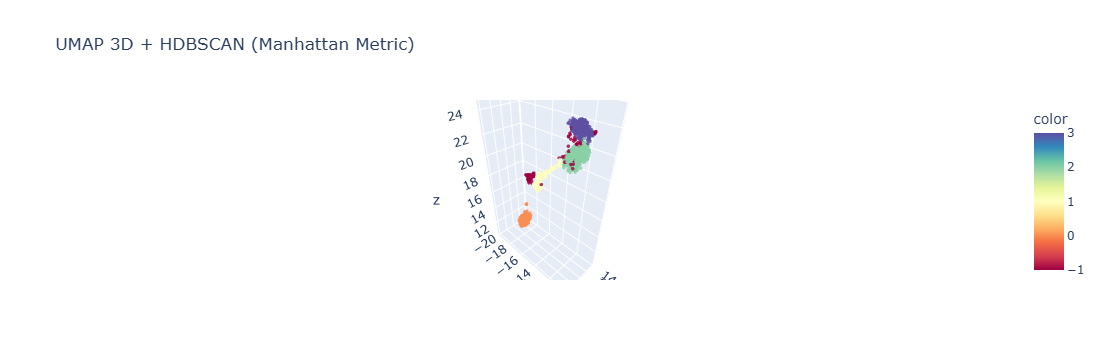

In [15]:
fig = px.scatter_3d(
    x=X_umap3[:, 0],
    y=X_umap3[:, 1],
    z=X_umap3[:, 2],
    color=hdb_labels,
    title="UMAP 3D + HDBSCAN (Manhattan Metric)",
    opacity=0.8,
    color_continuous_scale="Spectral"
)
fig.update_traces(marker=dict(size=2))
fig.show()

#### Clusters Evaluation

In [16]:
df_3.groupby("HDBSCAN_Cluster")[["Neighborhood", "LotArea", "HouseStyle", "RoofStyle"]].mean()

,Neighborhood,LotArea,HouseStyle,RoofStyle
HDBSCAN_Cluster,,,,
-1,11.726667,7307.233333,2.233333,1.406667
0,12.397333,9755.301333,4.938667,1.306667
1,13.254545,11293.627273,2.150000,1.513636
2,12.637363,10141.307692,2.750000,1.554945
3,10.859375,8684.695312,1.894531,1.199219


In [19]:
pd.crosstab(df_3["HDBSCAN_Cluster"], df_3["HouseStyle"], normalize="columns") * 100

HouseStyle,0,1,2,3,4,5,6,7
HDBSCAN_Cluster,,,,,,,,
-1,10.204082,7.142857,17.282127,0.000000,0.0,1.927711,8.333333,9.523810
0,7.482993,0.000000,0.147710,33.333333,0.0,81.445783,19.444444,25.396825
1,0.680272,0.000000,31.166913,0.000000,0.0,0.240964,8.333333,6.349206
2,1.360544,21.428571,44.017725,0.000000,0.0,0.240964,63.888889,58.730159
3,80.272109,71.428571,7.385524,66.666667,100.0,16.144578,0.000000,0.000000


The clusters differ a lot by LotArea and also by HouseStyle.

**Clusters are not random:** they’re strongly tied to certain HouseStyle categories.

Further investigations are needed to define the nature of these clusters.

### Comparison Table: KMeans vs. HDBSCAN

In [58]:
cluster_results = [
    {
        "Model": "KMeans",
        "k": k,
        "Silhouette": sil_km,
        "DaviesBouldin": db_km,
        "CalinskiHarabasz": ch_km,
        "Stability_ARI": stability_km,
    },
    {
        "Model": "HDBSCAN",
        "k": len(set(hdb_labels) - {-1}),  # Number of clusters excluding noise
        "Silhouette": sil_hdb,
        "DaviesBouldin": db_hdb,
        "CalinskiHarabasz": ch_hdb,
        "Stability_ARI": stability_hdb,
    }
]

cluster_results_df = pd.DataFrame(cluster_results)
display(cluster_results_df)

,Model,k,Silhouette,DaviesBouldin,CalinskiHarabasz,Stability_ARI
0,KMeans,11,0.070081,3.105523,134.573793,0.364936
1,HDBSCAN,4,0.693643,0.422194,17654.169922,0.974143


### Visual Comparison of Clustering Metrics

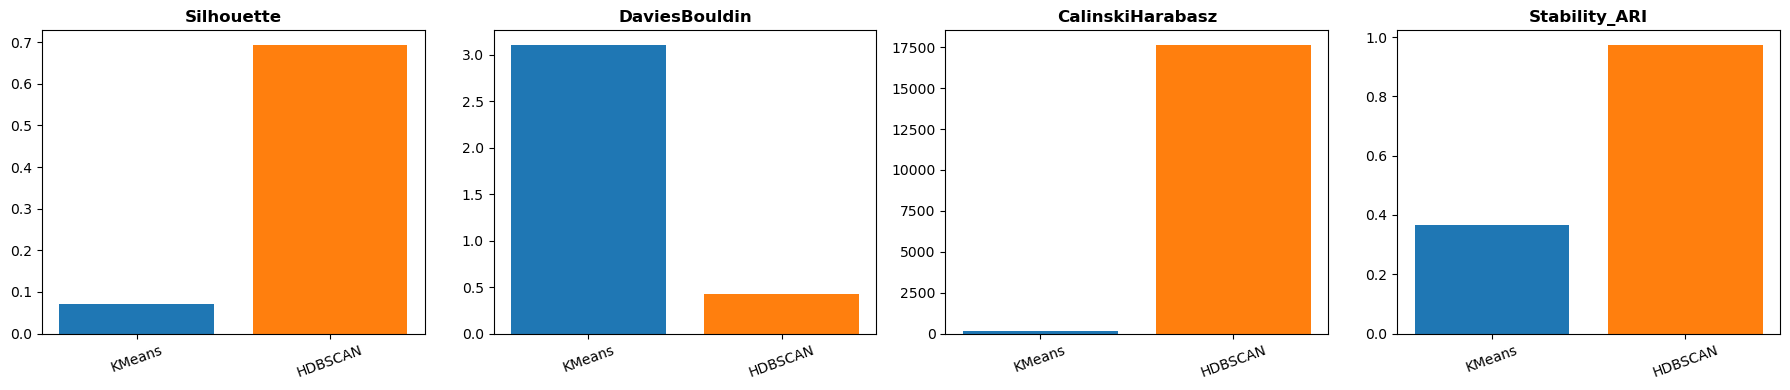

In [59]:
metrics = ["Silhouette", "DaviesBouldin", "CalinskiHarabasz", "Stability_ARI"]

# Create a 1x4 subplot canvas for side-by-side metric comparison
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, m in enumerate(metrics):
    ax = axes[i]
    
    # Plot bars for KMeans vs. HDBSCAN for the current metric
    # Added basic colors for better visual distinction in your portfolio
    ax.bar(cluster_results_df["Model"], cluster_results_df[m], color=["#1f77b4", "#ff7f0e"])
    
    ax.set_title(m, fontsize=12, fontweight="bold")
    
    # Define ticks explicitly before setting labels to avoid Matplotlib warnings
    ax.set_xticks(range(len(cluster_results_df["Model"])))
    ax.set_xticklabels(cluster_results_df["Model"], rotation=20)

# Adjust layout to prevent overlapping titles or labels
plt.tight_layout()
plt.show()

## Final Verdict
HDBSCAN clearly outperforms KMeans across all evaluation metrics.

It achieves a much higher Silhouette score and a significantly lower Davies-Bouldin index, indicating better cluster separation and compactness.
The Calinski-Harabasz score is dramatically higher for HDBSCAN, confirming stronger inter-cluster dispersion.
Additionally, HDBSCAN shows near-perfect stability, demonstrating far more consistent clustering results.

By combining UMAP with HDBSCAN, the model successfully isolated dense, organically shaped market segments while accurately flagging highly irregular properties as noise.

HDBSCAN is the superior choice for real-world market segmentation, while K-Means serves as a fast, highly interpretable baseline.